# <span style="color:#0b486b">  Student Information</span>
***
Surname: **Goh**  <br/>
Firstname: **Jia Xuan**    <br/>
Student ID: **33589666**    <br/>
Email: **jgoh0043@student.monash.edu**    <br/>
Your tutorial time: **Thursday 2-4pm**    <br/>
***

## <span style="color:#0b486b">Part 2: Deep Neural Networks (DNN) </span>
<div style="text-align: right"><span style="color:red; font-weight:bold">[Total marks for this part: 25 points]<span></div>

The second part of this assignment is to demonstrate your basis knowledge in deep learning that you have acquired from the lectures and tutorials materials. Most of the contents in this assignment are drawn from **the tutorials covered from weeks 1 to 2**. Going through these materials before attempting this assignment is highly recommended.

In the second part of this assignment, you are going to work with the FashionMNIST dataset for the image recognition task. It has the exact same format as MNIST (70,000 grayscale images of 28 × 28 pixels each with 10 classes), but the images represent fashion items rather than handwritten digits, so each class is more diverse, and the problem is significantly more challenging than MNIST.

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(1234)

**Load the Fashion MNIST using `torchvision`**

In [ ]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_dataset_orgin = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

print(train_dataset_orgin.data.shape, train_dataset_orgin.targets.shape)
print(test_dataset.data.shape, test_dataset.targets.shape)

# Flatten the data
train_dataset_orgin.data = train_dataset_orgin.data.reshape(-1, 28*28)
test_dataset.data = test_dataset.data.reshape(-1, 28*28)

print(train_dataset_orgin.data.shape, train_dataset_orgin.targets.shape)
print(test_dataset.data.shape, test_dataset.targets.shape)

N = len(train_dataset_orgin)
print(f"Number of training samples: {N}")
N_train = int(0.9*N)
N_val = N - N_train
print(f"Number of training samples: {N_train}")
print(f"Number of validation samples: {N_val}")

train_dataset, val_dataset = torch.utils.data.random_split(train_dataset_orgin, [N_train, N_val])


print(len(train_dataset))
print(len(val_dataset))


train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.5MB/s]

torch.Size([60000, 28, 28]) torch.Size([60000])
torch.Size([10000, 28, 28]) torch.Size([10000])
torch.Size([60000, 784]) torch.Size([60000])
torch.Size([10000, 784]) torch.Size([10000])
Number of training samples: 60000
Number of training samples: 54000
Number of validation samples: 6000
54000
6000


####  <span style="color:red">**Question 2.1:**</span> Write the code to visualize a mini-batch in `train_loader` including its images and labels.

<div style="text-align: right"> <span style="color:red">[5 points]</span> </div>

In [ ]:
class_names = train_dataset_orgin.classes
print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


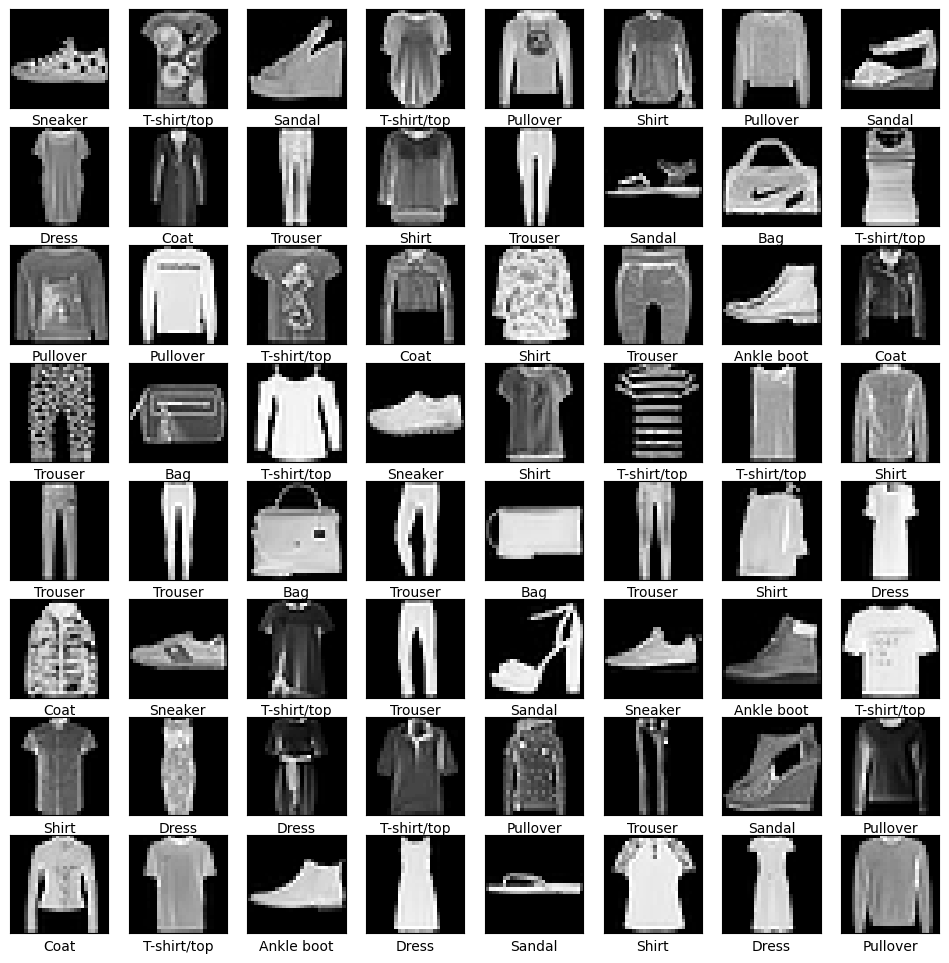

In [ ]:
#Your code here
import matplotlib.pyplot as plt
%matplotlib inline
import math
import numpy as np

def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    #img = img.numpy()
    plt.imshow(img, cmap="gray")


def visualize_data(images, categories, class_names, images_per_row = 8):
    n_images = len(images)
    n_rows = math.ceil(float(n_images)/images_per_row)
    fig = plt.figure(figsize=(1.5*images_per_row, 1.5*n_rows))
    fig.patch.set_facecolor('white')
    for i in range(n_images):
        plt.subplot(n_rows, images_per_row, i+1)
        plt.xticks([])
        plt.yticks([])
        # Reshape the flattened image back to 28x28 before displaying
        imshow(images[i].reshape(28, 28))
        class_index = categories[i]
        plt.xlabel(class_names[class_index])
    plt.show()

# obtain one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
#images = images.numpy() # convert images to numpy for display

visualize_data(images, labels, class_names)

:####<span style="color:red">**Question 2.2:**</span> Write the code for the feed-forward neural net using PyTorch

<div style="text-align: right"> <span style="color:red">[5 points]</span> </div>

We now develop a feed-forward neural network with the architecture $784 \rightarrow 40(ReLU) \rightarrow 30(ReLU) \rightarrow 10(softmax)$. You can choose your own way to implement your network and an optimizer of interest. You should train model in $50$ epochs and evaluate the trained model on the test set.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

class FeedForwardNN(nn.Module):
    def __init__(self, input_size=784, hidden1=40, hidden2=30, output_size=10):
        super(FeedForwardNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)  # logits for softmax
        return x


In [ ]:
class FFNTrainer:
    def __init__(self, model, criterion, optimizer, n_features, train_loader, val_loader, verbose=False):
        self.model = model.to(device)
        self.criterion = criterion
        self.optimizer = optimizer
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.stop_training = False
        self.n_features = n_features
        self.verbose = verbose
        self.best_val_acc = 0.0

    def fit(self, num_epochs):
        self.num_batches = len(self.train_loader)

        for epoch in range(num_epochs):
            if self.stop_training:
                break

            train_loss, train_accuracy = self.train_one_epoch()
            val_loss, val_accuracy = self.validate_one_epoch()
            if self.verbose:
                msg = f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}"
                if val_accuracy is not None:
                    msg += f", Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f} (Best: {self.best_val_acc:.4f})"
                print(msg)

        print(f"Training complete. Highest validation accuracy: {self.best_val_acc:.4f}")

    def train_one_epoch(self):
        self.model.train()
        running_loss, correct, total = 0.0, 0, 0

        for i, data in enumerate(self.train_loader):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = inputs.reshape(-1, self.n_features)  ## NNEED?

            self.optimizer.zero_grad()
            outputs = self.model(inputs.float())
            loss = self.criterion(outputs, labels.long())
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = correct / total
        train_loss = running_loss / self.num_batches
        return train_loss, train_accuracy

    def validate_one_epoch(self):
        self.model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for data in self.val_loader:
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)
                inputs = inputs.reshape(-1, self.n_features)

                outputs = self.model(inputs.float())
                loss = self.criterion(outputs, labels.long())
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = correct / total
        val_loss = val_loss / len(self.val_loader)

        # Update best validation accuracy
        if val_accuracy > self.best_val_acc:
            self.best_val_acc = val_accuracy

        return val_loss, val_accuracy

    def on_epoch_end(self, params):  # end of each epoch what we want to do
        pass

    def evaluate(self, test_loader):
        self.model.eval()
        test_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                inputs = inputs.reshape(-1, self.n_features)
                inputs = inputs.float()
                labels = labels.long()

                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                test_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_loss /= len(test_loader)
        test_acc = correct / total
        print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc*100:.2f}%")
        return test_loss, test_acc

In [ ]:
model = FeedForwardNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_features = 28*28

trainer = FFNTrainer(model, criterion, optimizer, num_features, train_loader, val_loader, verbose=True)
trainer.fit(num_epochs=50)

Epoch 1/50 - Train Loss: 0.5754, Train Acc: 0.7969, Val Loss: 0.4823, Val Acc: 0.8250 (Best: 0.8250)
Epoch 2/50 - Train Loss: 0.4161, Train Acc: 0.8498, Val Loss: 0.4320, Val Acc: 0.8413 (Best: 0.8413)
Epoch 3/50 - Train Loss: 0.3803, Train Acc: 0.8617, Val Loss: 0.4262, Val Acc: 0.8420 (Best: 0.8420)
Epoch 4/50 - Train Loss: 0.3578, Train Acc: 0.8689, Val Loss: 0.3985, Val Acc: 0.8587 (Best: 0.8587)
Epoch 5/50 - Train Loss: 0.3417, Train Acc: 0.8750, Val Loss: 0.3834, Val Acc: 0.8620 (Best: 0.8620)
Epoch 6/50 - Train Loss: 0.3269, Train Acc: 0.8793, Val Loss: 0.3736, Val Acc: 0.8640 (Best: 0.8640)
Epoch 7/50 - Train Loss: 0.3175, Train Acc: 0.8831, Val Loss: 0.3663, Val Acc: 0.8682 (Best: 0.8682)
Epoch 8/50 - Train Loss: 0.3066, Train Acc: 0.8871, Val Loss: 0.3866, Val Acc: 0.8600 (Best: 0.8682)
Epoch 9/50 - Train Loss: 0.2969, Train Acc: 0.8915, Val Loss: 0.3796, Val Acc: 0.8678 (Best: 0.8682)
Epoch 10/50 - Train Loss: 0.2894, Train Acc: 0.8933, Val Loss: 0.4091, Val Acc: 0.8573 (Bes

In [ ]:
trainer.evaluate(test_loader)

Test Loss: 0.4442, Test Accuracy: 87.57%


(0.44420671463012695, 0.8757)

####  <span style="color:red">**Question 2.3:**</span> Tuning hyper-parameters with grid search
<div style="text-align: right"> <span style="color:red">[5 points]</span> </div>


Assume that you need to tune the number of neurons on the first and second hidden layers $n_1 \in \{20, 40\}$, $n_2 \in \{20, 40\}$  and the used activation function  $act \in \{sigmoid, tanh, relu\}$. The network has the architecture pattern $784 \rightarrow n_1 (act) \rightarrow n_2(act) \rightarrow 10(softmax)$ where $n_1, n_2$, and $act$ are in their grides. Write the code to tune the hyper-parameters $n_1, n_2$, and $act$. Note that you can freely choose the optimizer and learning rate of interest for this task.

In [ ]:
class CheckpointManager:
    def __init__(self, model, model_path='best_model.pth'):
        self.model = model
        self.model_path = model_path
        self.best_score = None

    def save_model(self, current_score, mode='loss'):
        if self.best_score is None or (mode == 'loss' and current_score < self.best_score) or (mode == 'accuracy' and current_score > self.best_score):
            self.best_score = current_score
            torch.save(self.model.state_dict(), self.model_path)  # save the model state
            #print(f"Model saved to {self.model_path}")

    def load_model(self):
        self.model.load_state_dict(torch.load(self.model_path))
        print(f"Model loaded from {self.model_path}")

In [ ]:
class CheckpointTrainer(FFNTrainer):
    def __init__(self, model, criterion, optimizer, train_loader, val_loader, model_saver_loader, mode="loss"):
        super().__init__(model, criterion, optimizer, num_features, train_loader, val_loader)
        self.model_saver_loader = model_saver_loader
        self.mode = mode

    def on_epoch_end(self, params):
        if self.mode == "loss":
            self.model_saver_loader.save_model(params["val_loss"], mode="loss")
        elif self.mode == "accuracy":
            self.model_saver_loader.save_model(params["val_accuracy"], mode="accuracy")

In [ ]:
#Your code here
import torch
import torch.nn as nn
from torch import optim
from itertools import product
from torch.nn import Sequential, Linear

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Define available activation functions
activation_dict = {
    "relu": nn.ReLU(),
    "sigmoid": nn.Sigmoid(),
    "tanh": nn.Tanh()
}


def create_model(n1, n2, act, n_features, n_classes):
  dnn_model = Sequential(Linear(n_features,n1), act,
                        Linear(n1,n2), act,
                        Linear(n2, n_classes)).to(device)
  return dnn_model

In [ ]:
criterion = nn.CrossEntropyLoss()

# Define the grid of hyperparameters
n1_grid = [20, 40]
n2_grid = [20, 40]
activations = ["sigmoid", "tanh", "relu"]

best_acc = 0
best_params = None

# grid search try all combinations of n1, n2, act
for n1, n2, act in product(n1_grid, n2_grid, activations):
    print(f"\n=== Training model: n1={n1}, n2={n2}, activation={act} ===")
    model = create_model(n1, n2, activation_dict[act], num_features, len(class_names))
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    ckpt_loader = CheckpointManager(model, model_path="best_model.pth")
    trainer = CheckpointTrainer(model, criterion, optimizer,
                                train_loader, val_loader,
                                ckpt_loader, mode='accuracy')

    trainer.fit(num_epochs=10)

    # Evaluate on validation set
    #val_acc = trainer.validate_one_epoch()[1]  # returns (val_loss, val_accuracy)

    if trainer.best_val_acc > best_acc:
        best_acc = trainer.best_val_acc
        best_params = (n1, n2, act)
        torch.save(model.state_dict(), "best_overall_model.pth")


print("\n=== Grid Search Results ===")
print(f"Best Validation Accuracy: {best_acc*100:.2f}%")
print(f"Best Hyperparameters: n1={best_params[0]}, n2={best_params[1]}, activation={best_params[2]}")


=== Training model: n1=20, n2=20, activation=sigmoid ===
Training complete. Highest validation accuracy: 0.8558

=== Training model: n1=20, n2=20, activation=tanh ===
Training complete. Highest validation accuracy: 0.8657

=== Training model: n1=20, n2=20, activation=relu ===
Training complete. Highest validation accuracy: 0.8597

=== Training model: n1=20, n2=40, activation=sigmoid ===
Training complete. Highest validation accuracy: 0.8517

=== Training model: n1=20, n2=40, activation=tanh ===
Training complete. Highest validation accuracy: 0.8620

=== Training model: n1=20, n2=40, activation=relu ===
Training complete. Highest validation accuracy: 0.8697

=== Training model: n1=40, n2=20, activation=sigmoid ===
Training complete. Highest validation accuracy: 0.8688

=== Training model: n1=40, n2=20, activation=tanh ===
Training complete. Highest validation accuracy: 0.8713

=== Training model: n1=40, n2=20, activation=relu ===
Training complete. Highest validation accuracy: 0.8733



In [ ]:
best_n1, best_n2, best_act = best_params
best_model = create_model(best_n1, best_n2, activation_dict[best_act], num_features, len(class_names))
best_model.load_model()

# Wrap in FFNTrainer to use evaluate
trainer = FFNTrainer(best_model, criterion, optimizer=None, n_features=num_features,
                     train_loader=None, val_loader=None)
trainer.evaluate(test_loader)

Test Loss: 0.3546, Test Accuracy: 87.59%


(0.3545697182416916, 0.8759)

####  <span style="color:red">**Question 2.4:**</span> Implement the loss with the form: $loss(p,y)=CE(1_{y},p)+\lambda H(p)$ where $H(p)=-\sum_{i=1}^{M}p_{i}\log p_{i}$ is the entropy of $p$, $p$ is the prediction probabilities of a data point $x$ with the ground-truth label $y$, $1_y$ is an one-hot label, and $\lambda >0$ is a trade-off parameter. Set $\lambda = 0.1$ to train a model.

<div style="text-align: right"> <span style="color:red">[5 points]</span> </div>


In [ ]:
#Your code here

import torch
import torch.nn as nn

class EntropyRegularizedLoss(nn.Module):
    def __init__(self, lambda_reg=0.1):
        super().__init__()
        self.lambda_reg = lambda_reg
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, logits, targets):
        # Cross-entropy loss
        ce = self.ce_loss(logits, targets)

        # Convert logits -> probabilities using softmax
        probs = torch.softmax(logits, dim=1)

        # Entropy H(p) = -sum(p * log(p)) over classes
        entropy = -torch.sum(probs * torch.log(probs + 1e-12), dim=1).mean()

        # Total loss = CE + λ * H(p)
        loss = ce + self.lambda_reg * entropy
        return loss



In [ ]:
# 1. Recreate the same model architecture from best_params
best_n1, best_n2, best_act = best_params
model = create_model(best_n1, best_n2, activation_dict[best_act])

# 2. Attach checkpoint manager and load previously saved best weights
ckpt_loader = CheckpointManager(model, model_path="best_overall_model.pth")
ckpt_loader.load_model()

# 3. Define entropy-regularized loss function
lambda_reg = 0.1
loss_fn = EntropyRegularizedLoss(lambda_reg)

# 4. Define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 5. Use BaseTrainer to fine-tune the loaded model
trainer = FFNTrainer(
    model=model,
    criterion=loss_fn,
    optimizer=optimizer,
    num_features=num_features,
    train_loader=train_loader,
    val_loader=val_loader,
    verbose=True
)

# 6. Fine-tune model with new loss
trainer.fit(num_epochs=10)

# 7. Save a new checkpoint for the fine-tuned model
torch.save(model.state_dict(), "best_model_with_entropy.pth")


Model loaded from best_model.pth
Epoch 1/10
844/844 - loss: 0.4320 - accuracy: 0.8552 - val_loss: 0.4704 - val_accuracy: 0.8442
Epoch 2/10
844/844 - loss: 0.4035 - accuracy: 0.8636 - val_loss: 0.4956 - val_accuracy: 0.8423
Epoch 3/10
844/844 - loss: 0.3833 - accuracy: 0.8716 - val_loss: 0.4346 - val_accuracy: 0.8638
Epoch 4/10
844/844 - loss: 0.3759 - accuracy: 0.8741 - val_loss: 0.4708 - val_accuracy: 0.8488
Epoch 5/10
844/844 - loss: 0.3599 - accuracy: 0.8796 - val_loss: 0.4199 - val_accuracy: 0.8603
Epoch 6/10
844/844 - loss: 0.3549 - accuracy: 0.8817 - val_loss: 0.4222 - val_accuracy: 0.8632
Epoch 7/10
844/844 - loss: 0.3481 - accuracy: 0.8824 - val_loss: 0.4250 - val_accuracy: 0.8652
Epoch 8/10
844/844 - loss: 0.3385 - accuracy: 0.8865 - val_loss: 0.4226 - val_accuracy: 0.8705
Epoch 9/10
844/844 - loss: 0.3406 - accuracy: 0.8859 - val_loss: 0.3940 - val_accuracy: 0.8762
Epoch 10/10
844/844 - loss: 0.3283 - accuracy: 0.8899 - val_loss: 0.4285 - val_accuracy: 0.8620


In [ ]:
trainer = FFNTrainer(model, criterion=loss_fn, optimizer=None,
                     n_features=num_features,
                     train_loader=None, val_loader=None)
trainer.evaluate(test_loader)

Final Validation Accuracy with entropy regularization: 86.85%


####  <span style="color:red">**Question 2.5:**</span> Experimenting with **sharpness-aware minimization** technique
<div style="text-align: right"> <span style="color:red">[5 points]</span> </div>

Sharpness-aware minimization (SAM) (i.e., [link for main paper](https://openreview.net/pdf?id=6Tm1mposlrM) from Google Deepmind) is a simple yet but efficient technique to improve the generalization ability of deep learning models on unseen data examples. In your research or your work, you might potentially use this idea. Your task is to read the paper and implement *Sharpness-aware minimization (SAM)*. Finally, you need to apply SAM to the best architecture found in **Question 2.3**.   

In [ ]:
#Your code here
import torch
from torch.optim import Optimizer
from math import inf

class SAM(Optimizer):
    """
    Simple SAM wrapper. Usage:
      sam = SAM(model.parameters(), base_optimizer=torch.optim.SGD, rho=0.05, adaptive=False, lr=0.01, momentum=0.9)
    Then use sam like any optimizer but with special first_step/second_step pattern implemented in trainer.
    """
    def __init__(self, params, base_optimizer, rho=0.05, adaptive=False, **base_opt_kwargs):
        assert rho >= 0.0
        self.rho = rho
        self.adaptive = adaptive
        # instantiate the base optimizer with the params
        self.base_optimizer = base_optimizer(params, **base_opt_kwargs)
        # expose param_groups for compat
        self.param_groups = self.base_optimizer.param_groups
        self.state = self.base_optimizer.state

    def zero_grad(self):
        self.base_optimizer.zero_grad()

    def _grad_norm(self):
        # compute norm of gradients as in SAM paper (adaptive option available)
        device = device = next(iter(self.param_groups[0]['params'])).device
        norm = torch.norm(
            torch.stack([
                ((p.abs() if self.adaptive else 1.0) * p.grad).norm(p=2).to(device)
                for group in self.param_groups for p in group['params']
                if p.grad is not None
            ])
        )
        return norm

    def first_step(self, zero_grad=True):
        # ascend to the epsilon neighbor
        grad_norm = self._grad_norm()
        scale = self.rho / (grad_norm + 1e-12)

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                state = self.state[p]
                # e_w = (|p| * grad) * scale  if adaptive else grad * scale
                if self.adaptive:
                    e_w = (p.abs() * p.grad) * scale
                else:
                    e_w = p.grad * scale
                # save e_w for second step
                state['e_w'] = e_w
                p.data.add_(e_w)  # ascend

        if zero_grad:
            self.zero_grad()

    def second_step(self, zero_grad=True):
        # restore and do actual optimizer step using gradients at perturbed weights
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]
                e_w = state.get('e_w', None)
                if e_w is None:
                    continue
                p.data.sub_(e_w)  # restore original params
        # step the base optimizer with the gradients computed on perturbed weights
        self.base_optimizer.step()
        if zero_grad:
            self.zero_grad()

    # convenience: run base optimizer step only; not used for SAM flow
    def step(self, closure=None):
        return self.base_optimizer.step(closure)



In [ ]:
# 1. Recreate best model architecture
best_n1, best_n2, best_act = best_params
model = create_model(best_n1, best_n2, activation_dict[best_act], num_features, len(class_names)).to(device)

# 2. Load best weights using CheckpointManager
ckpt_loader = CheckpointManager(model, model_path="best_overall_model.pth")
ckpt_loader.load_model()

# 3. Define optimizer as SAM wrapper
sam = SAM(
    model.parameters(),
    base_optimizer=torch.optim.SGD,   # or Adam
    rho=0.05,
    adaptive=False,
    lr=0.01,
    momentum=0.9
)

loss_fn = nn.CrossEntropyLoss()
n_features = num_features
num_epochs = 15
for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        inputs = inputs.reshape(-1, n_features) # Use n_features here

        # === SAM: First forward-backward ===
        outputs = model(inputs.float())
        loss = loss_fn(outputs, labels.long())
        loss.backward()
        sam.first_step(zero_grad=True)

        # === SAM: Second forward-backward ===
        outputs_perturbed = model(inputs.float())
        loss_perturbed = loss_fn(outputs_perturbed, labels.long())
        loss_perturbed.backward()
        sam.second_step(zero_grad=True)

        # Accuracy tracking (use perturbed outputs)
        preds = torch.argmax(outputs_perturbed.detach(), dim=1)
        running_loss += loss_perturbed.item()
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    # Calculate metrics
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # Validation accuracy
    model.eval()
    correct_val, total_val = 0, 0
    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_inputs = val_inputs.reshape(-1, n_features)
            val_outputs = model(val_inputs.float())
            preds_val = torch.argmax(val_outputs, dim=1)
            total_val += val_labels.size(0)
            correct_val += (preds_val == val_labels).sum().item()
    val_acc = correct_val / total_val

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Model loaded from best_model.pth
Epoch [1/15] Train Loss: 0.3826 | Train Acc: 0.8695 | Val Acc: 0.8792
Epoch [2/15] Train Loss: 0.3675 | Train Acc: 0.8745 | Val Acc: 0.8777
Epoch [3/15] Train Loss: 0.3573 | Train Acc: 0.8786 | Val Acc: 0.8778
Epoch [4/15] Train Loss: 0.3506 | Train Acc: 0.8804 | Val Acc: 0.8792
Epoch [5/15] Train Loss: 0.3457 | Train Acc: 0.8824 | Val Acc: 0.8778
Epoch [6/15] Train Loss: 0.3399 | Train Acc: 0.8838 | Val Acc: 0.8797
Epoch [7/15] Train Loss: 0.3343 | Train Acc: 0.8858 | Val Acc: 0.8773
Epoch [8/15] Train Loss: 0.3298 | Train Acc: 0.8887 | Val Acc: 0.8783
Epoch [9/15] Train Loss: 0.3245 | Train Acc: 0.8894 | Val Acc: 0.8797
Epoch [10/15] Train Loss: 0.3199 | Train Acc: 0.8918 | Val Acc: 0.8798
Epoch [11/15] Train Loss: 0.3176 | Train Acc: 0.8921 | Val Acc: 0.8780
Epoch [12/15] Train Loss: 0.3131 | Train Acc: 0.8941 | Val Acc: 0.8767
Epoch [13/15] Train Loss: 0.3086 | Train Acc: 0.8945 | Val Acc: 0.8805
Epoch [14/15] Train Loss: 0.3066 | Train Acc: 0.8948 

In [ ]:
model.eval()
test_loss, correct_test, total_test = 0.0, 0, 0
with torch.no_grad():
    for test_inputs, test_labels in test_loader:
        test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)
        test_inputs = test_inputs.reshape(-1, num_features)
        test_outputs = model(test_inputs.float())
        tloss = loss_fn(test_outputs, test_labels.long())
        test_loss += tloss.item()
        preds_test = torch.argmax(test_outputs, dim=1)
        total_test += test_labels.size(0)
        correct_test += (preds_test == test_labels).sum().item()

test_loss = test_loss / len(test_loader)
test_acc = correct_test / total_test


Final Test Accuracy: 88.30%
Final Test Loss: 0.3813


---
### <span style="color:#0b486b"> <div  style="text-align:center">**THE END**</div> </span>